# Fully Bayesian Warp Regression

The intro notebook finds a **point** estimate of the warp path and map $f$ under the dual loss. Here the same kind of synthetic cycle gets a **posterior**: PyMC + NumPyro (JAX) on the full series, with amplitude $A \neq 1$ so the linear map is something to recover, not a fixed scale.

Observation model (here $f$ is linear):

$$\hat{y}_i = A \cdot \mathrm{warp}(x, p)_i + C.$$

We simulate from that map with known $A$, $C$, and knot path $p(B)$, then ask whether the posterior covers those values — including the terror scale $\sigma_t$.

## Dual likelihood at $\lambda = 0.5$

Training minimises $J = \lambda \cdot \mathrm{error} - (1-\lambda) \cdot \mathrm{terror}$. The Bayesian joint used here puts equal weight on both terms:

$$\log p(y, p \mid \theta) = -\mathrm{error} + \mathrm{terror}.$$

Soft-warp, path, and terror are the JAX kernels in `warp_regression.core.bayesian_jax` — the same math as PyTorch training, compiled for NumPyro NUTS.


In [1]:
%matplotlib inline

import sys
from pathlib import Path

for _p in (Path.cwd().resolve().parents[1] / "src", Path.cwd().resolve().parent):
    s = str(_p)
    if _p.is_dir() and s not in sys.path:
        sys.path.insert(0, s)

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import torch
import torch.nn as nn
from pymc.sampling.jax import sample_numpyro_nuts

from utils import build_synthetic_dataset
from warp_regression.core.bayesian_jax import (
    make_dual_logp_op,
    path_from_B,
    predict_from_params,
    soft_warp,
)
from warp_regression.core.path import path_from_B_torch
from warp_regression.core.training import compute_dual_loss
from warp_regression.core.warp import soft_warp_torch

rng = np.random.default_rng(0)


/Users/ap/Desktop/warp/warp_regression/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: data

Same sine cycle $x$ as the intro; $y$ is that cycle soft-warped, scaled by $A$, shifted by $C$, plus noise. Plotting $y$ against $x$ shows the timing mismatch the warp has to absorb.


/Users/ap/Desktop/warp/warp_regression/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


n=300  A_true=1.7  C_true=0.25  noise_std=0.2


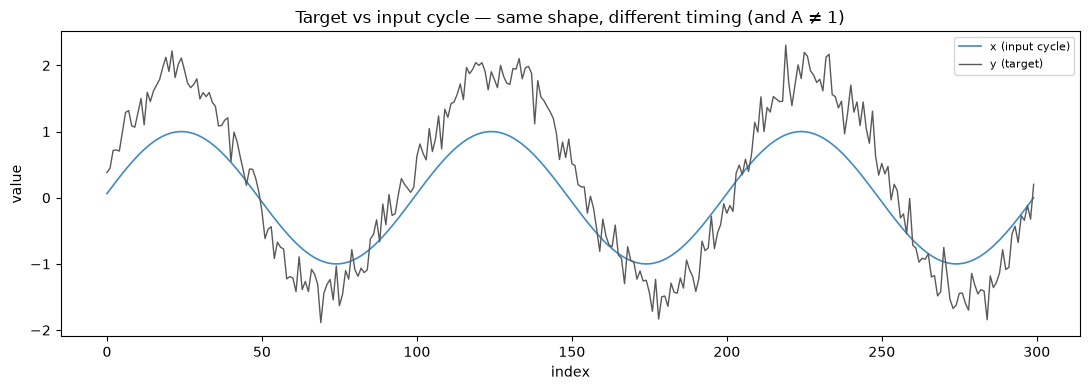

In [2]:
A_TRUE = 1.7
C_TRUE = 0.25
N_KNOTS = 8
LAM = 0.5
NOISE_STD = 0.2

data = build_synthetic_dataset()
n = data["n"]
x = data["x"]

# True knot coefficients → path → soft-warp
B_TRUE = np.array([0.0, 4.0, 8.0, 5.0, 0.0, -4.0, -7.0, -9.0], dtype=np.float64)
p_true = np.asarray(path_from_B(jnp.asarray(B_TRUE), n, N_KNOTS))
x_warped = np.asarray(soft_warp(jnp.asarray(x), jnp.asarray(p_true)))
y = A_TRUE * x_warped + C_TRUE + rng.normal(0.0, NOISE_STD, size=n)

print(f"n={n}  A_true={A_TRUE}  C_true={C_TRUE}  noise_std={NOISE_STD}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x, color="C0", lw=1.2, alpha=0.85, label="x (input cycle)")
ax.plot(y, color="0.35", lw=1.0, label="y (target)")
ax.set_xlabel("index")
ax.set_ylabel("value")
ax.set_title("Target vs input cycle — same shape, different timing (and A ≠ 1)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## Step 2: MAP warm-start

A short dual-loss fit (same objective as gradient training) starts NUTS near the mode.


In [3]:
x_t = torch.tensor(x, dtype=torch.float64)
y_t = torch.tensor(y, dtype=torch.float64)
B_t = nn.Parameter(torch.zeros(N_KNOTS, dtype=torch.float64))
A_t = nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
C_t = nn.Parameter(torch.tensor(0.0, dtype=torch.float64))
log_sy = nn.Parameter(torch.tensor(np.log(0.3), dtype=torch.float64))
log_st = nn.Parameter(torch.tensor(np.log(0.3), dtype=torch.float64))
opt = torch.optim.Adam([B_t, A_t, C_t, log_sy, log_st], lr=0.05)
for _ in range(3000):
    opt.zero_grad()
    p_t = path_from_B_torch(B_t, n, N_KNOTS)
    loss, _ = compute_dual_loss(
        y_t, A_t * soft_warp_torch(x_t, p_t) + C_t, p_t, log_sy, log_st, N_KNOTS, LAM,
    )
    loss.backward()
    opt.step()

map_init = {
    "B": B_t.detach().numpy().copy(),
    "A": np.array(float(A_t.detach())),
    "C": np.array(float(C_t.detach())),
    "sigma_y": np.array(float(torch.exp(log_sy).detach())),
    "sigma_t": np.array(float(torch.exp(log_st).detach())),
}
print(
    f"MAP  A={map_init['A']:.3f}  C={map_init['C']:.3f}  "
    f"σ_y={map_init['sigma_y']:.3f}  σ_t={map_init['sigma_t']:.3f}"
)


MAP  A=1.703  C=0.219  σ_y=0.201  σ_t=0.187


## Step 3: PyMC model

Priors on knot coefficients $B$, amplitude $A$, bias $C$, and scales $\sigma_y$, $\sigma_t$. The dual log-density enters as a `Potential` ($\lambda = 0.5$).


In [4]:
dual_op, _ = make_dual_logp_op(x, y, n_knots=N_KNOTS, lam=LAM)

with pm.Model() as model:
    B = pm.Normal("B", mu=0.0, sigma=30.0, shape=N_KNOTS)
    A = pm.Normal("A", mu=1.0, sigma=2.0)
    C = pm.Normal("C", mu=0.0, sigma=1.0)
    sigma_y = pm.HalfNormal("sigma_y", sigma=0.5)
    sigma_t = pm.HalfNormal("sigma_t", sigma=0.5)
    pm.Potential("dual", dual_op(B, A, C, sigma_y, sigma_t))

model


## Step 4: sample

`sample_numpyro_nuts` runs NUTS on the JAX-compiled model log-density.


In [5]:
with model:
    idata = sample_numpyro_nuts(
        draws=800,
        tune=800,
        chains=4,
        target_accept=0.9,
        random_seed=2,
        progressbar=True,
        initvals=map_init,
    )

print(az.summary(idata, var_names=["A", "C", "sigma_y", "sigma_t"], round_to=3))
print()
for name, truth in (("A", A_TRUE), ("C", C_TRUE), ("sigma_y", NOISE_STD)):
    lo = float(idata.posterior[name].quantile(0.025))
    hi = float(idata.posterior[name].quantile(0.975))
    mu = float(idata.posterior[name].mean())
    print(f"{name}: mean={mu:.3f}  95%[{lo:.3f}, {hi:.3f}]  true={truth}  covered={lo <= truth <= hi}")



  0%|          | 0/1600 [00:00<?, ?it/s]


Compiling.. :   0%|          | 0/1600 [00:00<?, ?it/s]


  0%|          | 0/1600 [00:00<?, ?it/s]


Compiling.. :   0%|          | 0/1600 [00:00<?, ?it/s]


  0%|          | 0/1600 [00:00<?, ?it/s]

...


Running chain 1: 100%|██████████| 1600/1600 [00:11<00:00, 253.44it/s]


Running chain 1: 100%|██████████| 1600/1600 [00:11<00:00, 134.82it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


          mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
A        1.702  0.017     1.674     1.729  1830.912  1577.363  1.001   
C        0.220  0.017     0.194     0.247  1681.938  1421.698  1.004   
sigma_y  0.205  0.008     0.191     0.218  1656.599  1614.974  1.005   
sigma_t  0.150  0.062     0.055     0.248   734.959   780.198  1.001   

         mcse_mean  mcse_sd  
A            0.000    0.000  
C            0.000    0.000  
sigma_y      0.000    0.000  
sigma_t      0.002    0.001  

A: mean=1.702  95%[1.668, 1.734]  true=1.7  covered=True
C: mean=0.220  95%[0.187, 0.253]  true=0.25  covered=True
sigma_y: mean=0.205  95%[0.188, 0.222]  true=0.2  covered=True


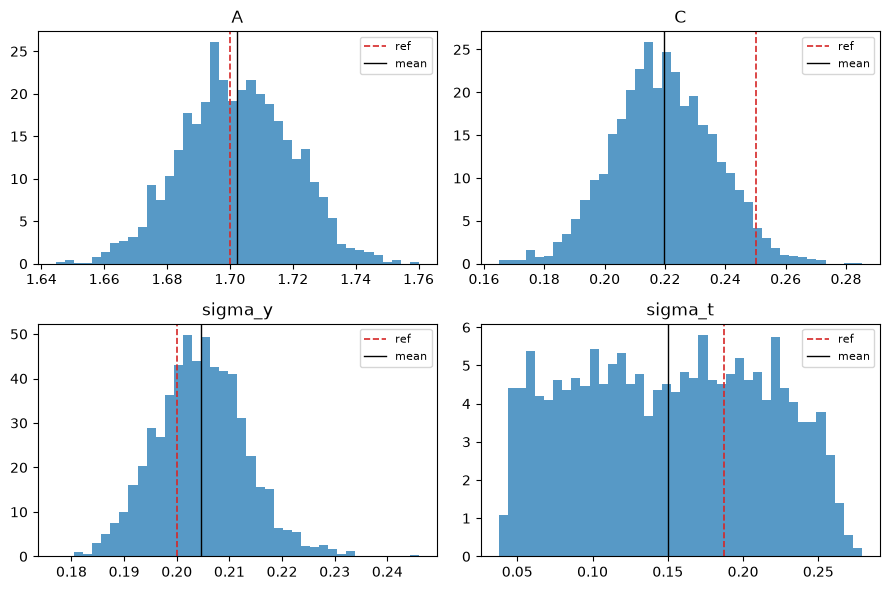

In [6]:
refs = {"A": A_TRUE, "C": C_TRUE, "sigma_y": NOISE_STD, "sigma_t": float(map_init["sigma_t"])}
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for ax, name in zip(axes.ravel(), refs):
    samples = np.asarray(idata.posterior[name]).ravel()
    ax.hist(samples, bins=40, color="C0", alpha=0.75, density=True)
    ax.axvline(refs[name], color="C3", ls="--", lw=1.2, label="ref")
    ax.axvline(samples.mean(), color="k", lw=1.0, label="mean")
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Step 5: posterior fit

Draws of $(B, A, C)$ give $\hat{y} = A \cdot \mathrm{warp}(x, p) + C$. Overlay on $y$ and the raw cycle $x$ — the gap between $x$ and the fit is the warp.


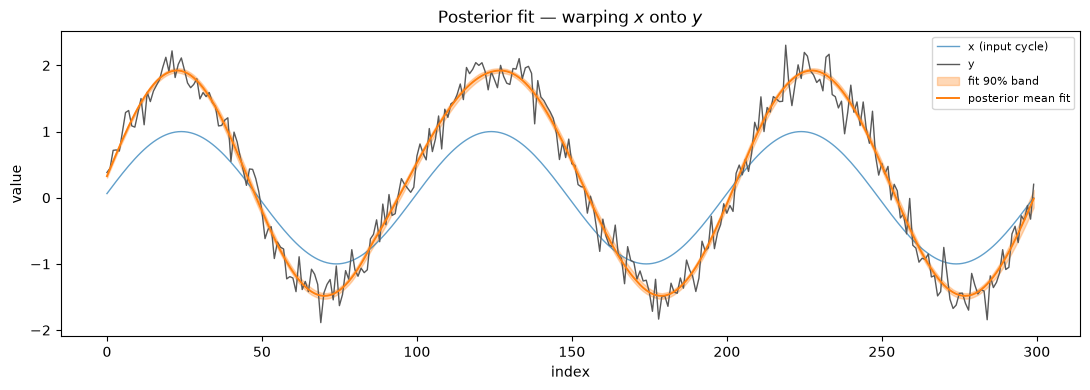

In [7]:
post = idata.posterior
b_dim = [d for d in post["B"].dims if d not in ("chain", "draw")][0]
B_s = np.asarray(post["B"].stack(sample=("chain", "draw")).transpose("sample", b_dim))
A_s = np.asarray(post["A"].stack(sample=("chain", "draw")))
C_s = np.asarray(post["C"].stack(sample=("chain", "draw")))

n_show = min(80, B_s.shape[0])
idx_show = rng.choice(B_s.shape[0], size=n_show, replace=False)

y_hat_samples = []
x_j = jnp.asarray(x)
for i in idx_show:
    y_hat_i, _ = predict_from_params(
        jnp.asarray(B_s[i]), float(A_s[i]), float(C_s[i]), x_j, N_KNOTS,
    )
    y_hat_samples.append(np.asarray(y_hat_i))

y_hat_samples = np.stack(y_hat_samples)
y_hat_mean = y_hat_samples.mean(axis=0)
y_q = np.quantile(y_hat_samples, [0.05, 0.95], axis=0)

idx = np.arange(n)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(idx, x, color="C0", lw=1.0, alpha=0.7, label="x (input cycle)")
ax.plot(idx, y, color="0.35", lw=1.0, label="y")
ax.fill_between(idx, y_q[0], y_q[1], color="C1", alpha=0.3, label="fit 90% band")
ax.plot(idx, y_hat_mean, color="C1", lw=1.4, label="posterior mean fit")
ax.set_xlabel("index")
ax.set_ylabel("value")
ax.set_title("Posterior fit — warping $x$ onto $y$")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## Takeaway

Point estimates under the dual loss become full posteriors on $A$, $C$, the path knots, and both scales. With $\lambda = 0.5$ the error and terror terms share the joint; JAX + NumPyro is the sampler sitting on the same soft-warp / terror geometry as training.
